<a href="https://colab.research.google.com/github/tasninkhanlamha/SkillMorph/blob/main/Android_Ransomware_Detection_%20alamgir_with_preprocess_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Android Ransomware Detection Detection**

## **Font family setup**

In [1]:
import matplotlib
# Set font size and family for the entire figure
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['font.family'] = 'serif'

In [ ]:
#Dataset Link: https://www.kaggle.com/datasets/subhajournal/android-ransomware-detection

## **Importing Dataset**

In [2]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Access the file in Google Drive
df = pd.read_csv("/content/drive/MyDrive/Skill-Morph/android_ransomware_preprocessed.csv")

## **Basic Information**

In [4]:
df

,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,6,151054,6,8,1076.0,4575.0,821.0,0.0,179.333333,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,443,6,349,2,0,23.0,0.0,23.0,0.0,11.500000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,443,6,119,2,0,23.0,0.0,23.0,0.0,11.500000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,443,6,37055,1,1,31.0,0.0,31.0,31.0,31.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,443,6,178727,6,7,1313.0,307.0,753.0,0.0,218.833333,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392029,53,17,24707,1,1,48.0,199.0,48.0,48.0,48.000000,...,44,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
392030,123,17,81388,1,1,48.0,48.0,48.0,48.0,48.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
392031,53,17,61591,1,1,39.0,98.0,39.0,39.0,39.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
392032,53,17,24831,1,1,36.0,153.0,36.0,36.0,36.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10


In [5]:
df.shape

(392034, 79)

In [6]:
df['Label'].value_counts()

,count
Label,
8,54161
6,46082
3,44555
0,43091
7,39859
1,39551
9,36340
10,32701
2,25672


## **Data Samples per Class**

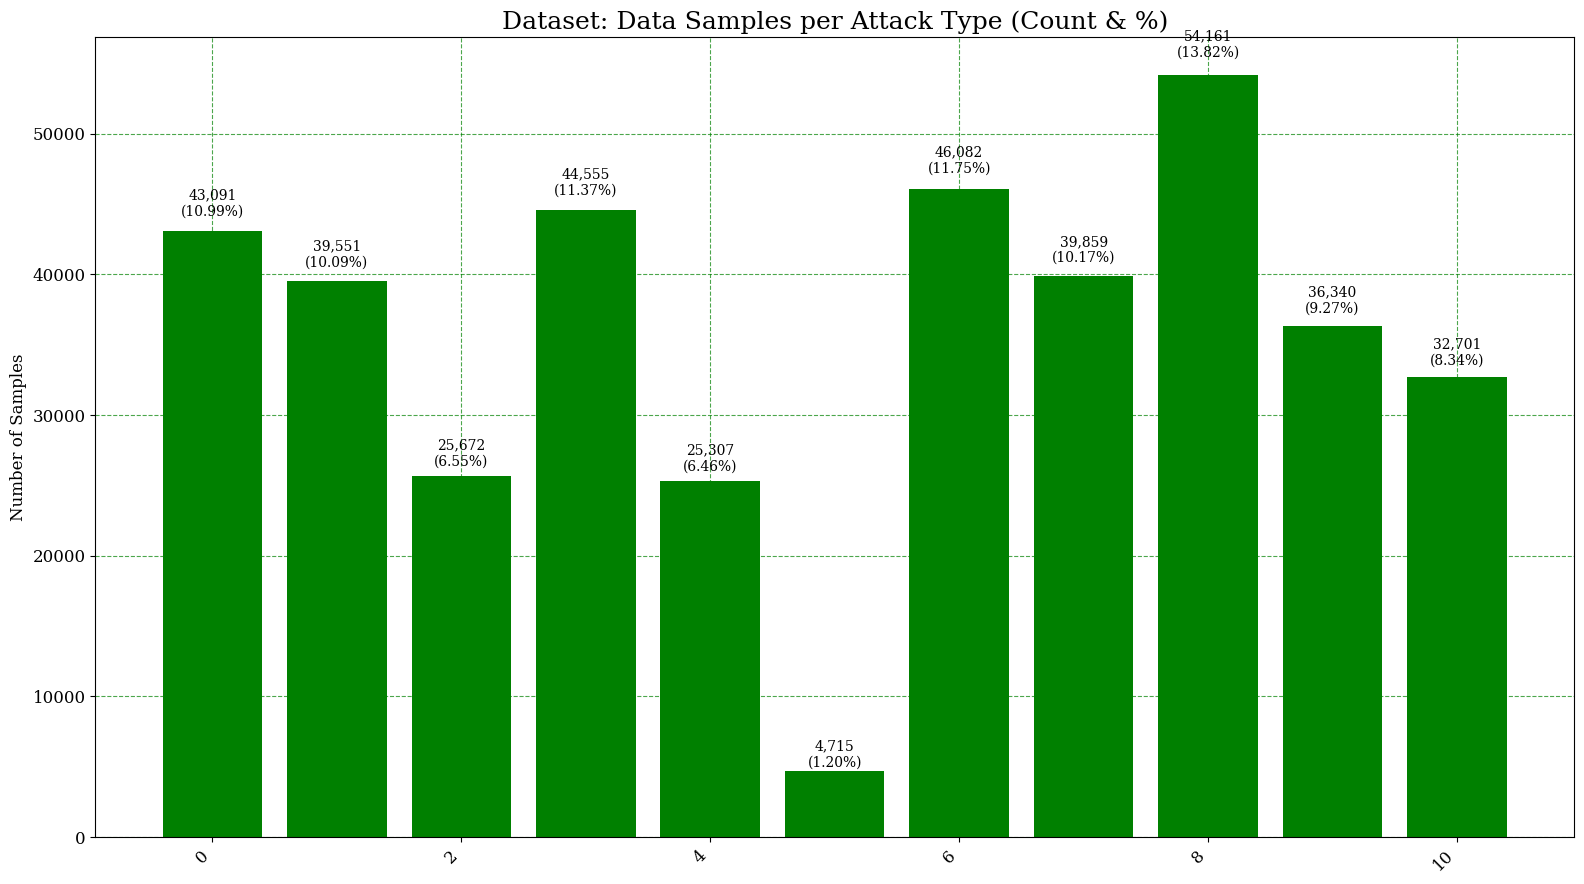

In [7]:
import matplotlib.pyplot as plt

# Count samples and percentages
label_counts = df['Label'].value_counts()
label_percentages = (label_counts / label_counts.sum()) * 100

# Set up the plot
plt.figure(figsize=(16, 9))
bars = plt.bar(label_counts.index, label_counts.values, color='green')  # Bar color set to green

# Add count and percentage text above each bar
for idx, bar in enumerate(bars):
    height = bar.get_height()
    count_text = f'{label_counts.values[idx]:,}'
    percent_text = f'({label_percentages.values[idx]:.2f}%)'

    plt.text(
        bar.get_x() + bar.get_width()/2, height + 0.02*height,
        f'{count_text}\n{percent_text}',
        ha='center', va='bottom', fontsize=10
    )

# Titles and labels
plt.title('Dataset: Data Samples per Attack Type (Count & %)', fontsize=18)
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
#plt.grid(axis='y', linestyle='--', alpha=0.7, color='green')  # Grid color set to green
# Enable both horizontal and vertical green grid lines
plt.grid(axis='both', linestyle='--', alpha=0.7, color='green')

plt.tight_layout()

# Show plot
plt.show()


## **Handle Missing Values**

In [10]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Only show columns with missing values

print("Columns with Missing Values:\n", missing_values)


# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Fill missing values in numerical columns with median
if not numerical_cols.empty:
    df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

# Fill missing values in categorical columns with mode
# Only attempt to fill if there are categorical columns
if not categorical_cols.empty:
    for col in categorical_cols:
        mode_val = df[col].mode()
        if not mode_val.empty:
            df[col] = df[col].fillna(mode_val.iloc[0])
        else:
            print(f"Warning: No mode found for column '{col}'. Skipping fillna.")
else:
    print("No object-type categorical columns found for filling missing values.")


# Verify if missing values are filled
print("Missing values after filling:\n", df.isnull().sum().sum())  # Should be 0 if all missing values are handled


Columns with Missing Values:
 Series([], dtype: int64)
No object-type categorical columns found for filling missing values.
Missing values after filling:
 0


In [11]:
# Print the names of the features (columns)
print(df.columns)

Index(['Destination Port', 'Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       

## **Data Preprocessing**

In [12]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

## Preprocessing steps
# Replace infinity and large values with NaNs
df = df.replace([np.inf, -np.inf], np.nan)
df = df.replace(to_replace=[r'^(-?\d+\.\d+e\+\d+|-?\d+\.\d+e-\d+|-?\d+\.\d+|-?\d+)$', r'^(-?\d+)$'], value=np.nan, regex=True)

# Drop rows containing NaNs
df.dropna(inplace=True)

# Separate numerical and categorical columns, excluding the 'Label' column from categorical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols = cat_cols.difference(['Label'])

# Normalize numerical columns
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# Ensure all categorical values are strings
df[cat_cols] = df[cat_cols].astype(str)

# Encode categorical columns
encoder = LabelEncoder()
df[cat_cols] = df[cat_cols].apply(encoder.fit_transform)

# Display the processed DataFrame
df

,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,-0.358896,-0.515637,-0.479042,-0.032246,-0.008793,0.011525,-0.034386,1.026506,-0.222340,0.910006,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,-1.546331
1,-0.358896,-0.515637,-0.485900,-0.151883,-0.107620,-0.051826,-0.076005,-0.367456,-0.222340,-0.377920,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,-1.546331
2,-0.358896,-0.515637,-0.485911,-0.151883,-0.107620,-0.051826,-0.076005,-0.367456,-0.222340,-0.377920,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,-1.546331
3,-0.358896,-0.515637,-0.484230,-0.181792,-0.095267,-0.051344,-0.076005,-0.353481,0.298340,-0.228280,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,-1.546331
4,-0.358896,-0.515637,-0.477782,-0.032246,-0.021147,0.025783,-0.073212,0.907722,-0.222340,1.213123,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,-1.546331
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392029,-0.384353,1.874255,-0.484792,-0.181792,-0.095267,-0.050322,-0.074195,-0.323785,0.583875,-0.097825,...,0.002826,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,1.496569
392030,-0.379784,1.874255,-0.482212,-0.181792,-0.095267,-0.050322,-0.075569,-0.323785,0.583875,-0.097825,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,1.496569
392031,-0.384353,1.874255,-0.483113,-0.181792,-0.095267,-0.050863,-0.075114,-0.339507,0.432709,-0.166890,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,1.496569
392032,-0.384353,1.874255,-0.484786,-0.181792,-0.095267,-0.051044,-0.074613,-0.344747,0.382321,-0.189911,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,1.496569


In [15]:
# df.drop(columns=['Unnamed: 0'], inplace=True) # This line caused an error as the column was not found.

In [ ]:
df

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,151298,14,0.662205,1328,-0.358896,-0.515637,4,-0.479042,-0.032246,-0.008793,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,Benign
1,151298,14,0.662205,1328,-0.358896,-0.515637,4,-0.485900,-0.151883,-0.107620,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,Benign
2,148227,14,-0.238766,1294,-0.358896,-0.515637,7,-0.485911,-0.151883,-0.107620,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,Benign
3,142970,14,0.903302,1247,-0.358896,-0.515637,8,-0.484230,-0.181792,-0.095267,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,Benign
4,151270,14,0.330548,1328,-0.358896,-0.515637,9,-0.477782,-0.032246,-0.021147,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392029,26058,13,0.814087,19,-0.384353,1.874255,27131,-0.484792,-0.181792,-0.095267,...,0.002826,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,WannaLocker
392030,53062,13,-0.222643,4986,-0.379784,1.874255,27059,-0.482212,-0.181792,-0.095267,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,WannaLocker
392031,15022,13,-0.834362,19,-0.384353,1.874255,27064,-0.483113,-0.181792,-0.095267,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,WannaLocker
392032,17539,13,-0.445790,19,-0.384353,1.874255,27120,-0.484786,-0.181792,-0.095267,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,WannaLocker


## **After Processing**

In [16]:
df['Label'].value_counts()

,count
Label,
0.887989,54161
0.279409,46082
-0.633461,44555
-1.546331,43091
0.583699,39859
-1.242041,39551
1.192279,36340
1.496569,32701
-0.937751,25672


In [17]:
####Copy the processed df to different df

df1 = df.copy()
df2 = df.copy()

# **Binary Class (Anomaly) Classification**

In [25]:
df1['Label'] = df1['Label'].apply(lambda x: 'Benign' if x == '0' else '1')

In [26]:
# Check counts
print(df1['Label'].value_counts())

Label
1    392034
Name: count, dtype: int64


In [20]:
# Define label and feature columns
X = df1.drop(columns=['Label'])
y = df1['Label']

## **Traing and Test Division**

In [22]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                   # Features and target
    test_size=0.2,          # 20% test, 80% train
    random_state=42,        # For reproducibility
)

# Confirm sizes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape: (313627, 78)
X_test shape:  (78407, 78)
y_train shape: (313627,)
y_test shape:  (78407,)


## **Train & Evaluate Decision Tree Classifier**

Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


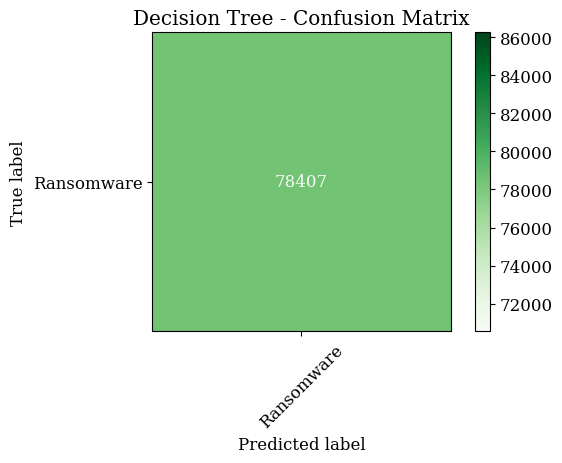

Classification Report:
              precision    recall  f1-score   support

  Ransomware    1.00000   1.00000   1.00000     78407

    accuracy                        1.00000     78407
   macro avg    1.00000   1.00000   1.00000     78407
weighted avg    1.00000   1.00000   1.00000     78407



In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = dt_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=dt_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate Random Forest Classifier**

Accuracy:  1.00000
Precision: 1.00000
Recall:    1.00000
F1 Score:  1.00000


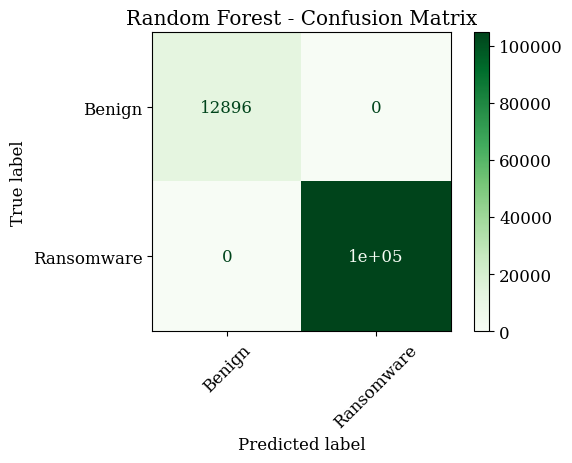

Classification Report:
              precision    recall  f1-score   support

      Benign    1.00000   1.00000   1.00000     12896
  Ransomware    1.00000   1.00000   1.00000    104715

    accuracy                        1.00000    117611
   macro avg    1.00000   1.00000   1.00000    117611
weighted avg    1.00000   1.00000   1.00000    117611



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=10, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = rf_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=rf_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate KNN Classifier**

Accuracy:  0.99957
Precision: 0.99957
Recall:    0.99957
F1 Score:  0.99957


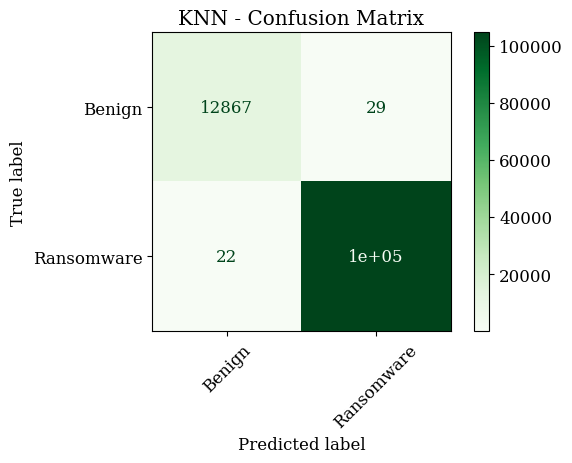

Classification Report:
              precision    recall  f1-score   support

      Benign    0.99829   0.99775   0.99802     12896
  Ransomware    0.99972   0.99979   0.99976    104715

    accuracy                        0.99957    117611
   macro avg    0.99901   0.99877   0.99889    117611
weighted avg    0.99957   0.99957   0.99957    117611



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train KNN Classifier
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can tune n_neighbors
knn_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = knn_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=knn_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("KNN - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

# **Multiclass Classification**

In [ ]:
# Define label and feature columns
X = df2.drop(columns=['Label'])
y = df2['Label']

## **Traing and Test Division**

In [ ]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                   # Features and target
    test_size=0.2,          # 20% test, 80% train
    random_state=42,        # For reproducibility
    stratify=y              # Ensures class distribution is preserved
)

# Confirm sizes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape: (313627, 84)
X_test shape:  (78407, 84)
y_train shape: (313627,)
y_test shape:  (78407,)


## **Train & Evaluate Decision Tree Classifier**

Accuracy:  0.9973
Precision: 0.9973
Recall:    0.9973
F1 Score:  0.9973


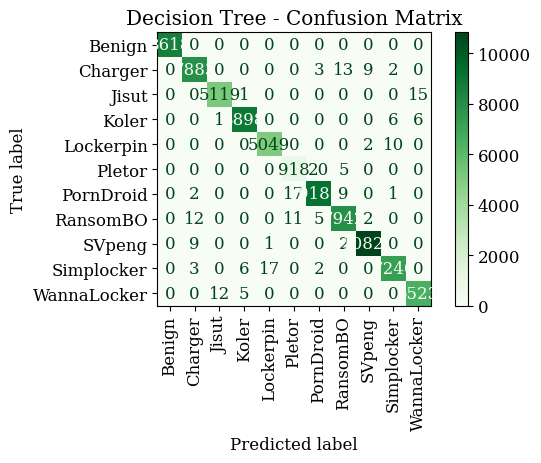

Classification Report:
              precision    recall  f1-score   support

      Benign    1.00000   1.00000   1.00000      8618
     Charger    0.99671   0.99659   0.99665      7910
       Jisut    0.99747   0.99688   0.99718      5135
       Koler    0.99865   0.99854   0.99860      8911
   Lockerpin    0.99645   0.99763   0.99704      5061
      Pletor    0.97040   0.97349   0.97194       943
   PornDroid    0.99675   0.99685   0.99680      9217
    RansomBO    0.99636   0.99624   0.99630      7972
      SVpeng    0.99880   0.99889   0.99885     10832
  Simplocker    0.99738   0.99615   0.99676      7268
 WannaLocker    0.99679   0.99740   0.99710      6540

    accuracy                        0.99733     78407
   macro avg    0.99507   0.99533   0.99520     78407
weighted avg    0.99734   0.99733   0.99733     78407



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = dt_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=dt_model.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate Random Forest Classifier**

Accuracy:  0.95203
Precision: 0.95208
Recall:    0.95203
F1 Score:  0.95168


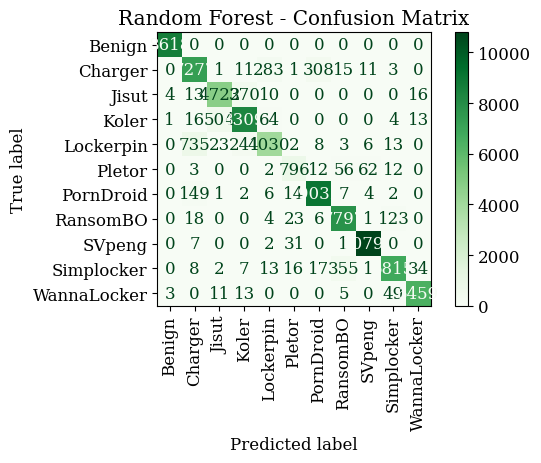

Classification Report:
              precision    recall  f1-score   support

      Benign    0.99907   1.00000   0.99954      8618
     Charger    0.88463   0.91997   0.90196      7910
       Jisut    0.89704   0.91957   0.90816      5135
       Koler    0.92807   0.93244   0.93025      8911
   Lockerpin    0.91300   0.79629   0.85066      5061
      Pletor    0.90147   0.84411   0.87185       943
   PornDroid    0.96259   0.97993   0.97118      9217
    RansomBO    0.94635   0.97805   0.96194      7972
      SVpeng    0.99218   0.99621   0.99420     10832
  Simplocker    0.97066   0.93767   0.95388      7268
 WannaLocker    0.99034   0.98761   0.98898      6540

    accuracy                        0.95203     78407
   macro avg    0.94413   0.93562   0.93933     78407
weighted avg    0.95208   0.95203   0.95168     78407



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators = 10, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=rf_model.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate KNN Classifier**

Accuracy:  0.96185
Precision: 0.96191
Recall:    0.96185
F1 Score:  0.96186


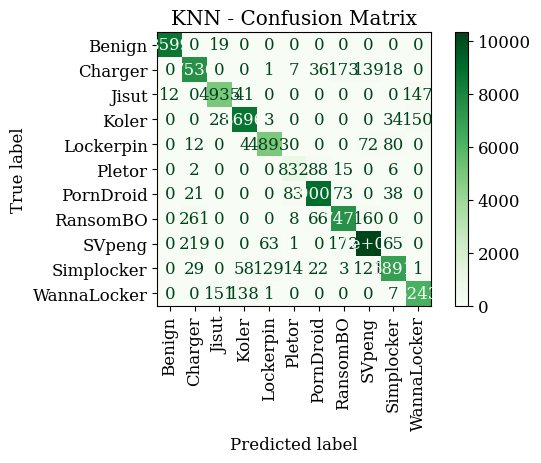

Classification Report:
              precision    recall  f1-score   support

      Benign    0.99861   0.99780   0.99820      8618
     Charger    0.93267   0.95272   0.94259      7910
       Jisut    0.96143   0.96105   0.96124      5135
       Koler    0.97303   0.97587   0.97445      8911
   Lockerpin    0.96130   0.96680   0.96404      5061
      Pletor    0.88042   0.88229   0.88136       943
   PornDroid    0.97699   0.97667   0.97683      9217
    RansomBO    0.94490   0.93791   0.94139      7972
      SVpeng    0.95446   0.95199   0.95323     10832
  Simplocker    0.96526   0.94813   0.95662      7268
 WannaLocker    0.95444   0.95459   0.95451      6540

    accuracy                        0.96185     78407
   macro avg    0.95487   0.95507   0.95495     78407
weighted avg    0.96191   0.96185   0.96186     78407



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train KNN Classifier
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can tune n_neighbors
knn_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = knn_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=knn_model.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("KNN - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

# **Modified Confusion Matrix**

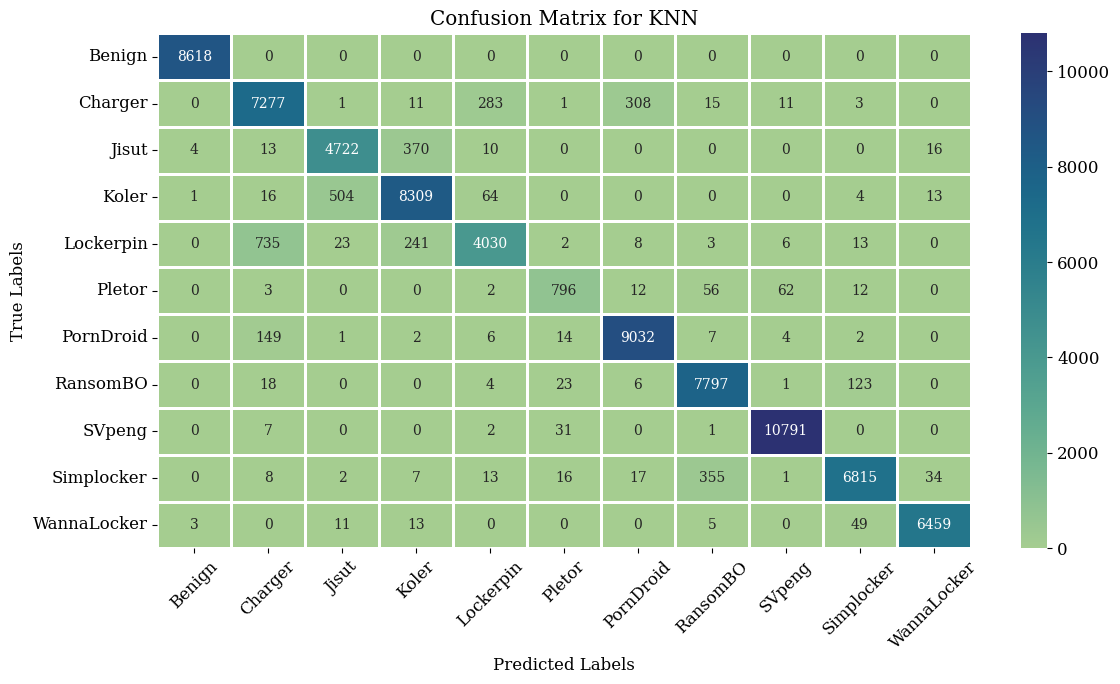

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = confusion_matrix(y_test, y_pred)

# Colormap
cmap = sns.color_palette("crest", as_cmap=True)

# Automatically get class labels from model
class_labels = knn_model.classes_

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 7))

# Plot CM
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=True,
            ax=ax, annot_kws={"fontsize": 10}, linewidths=1, linecolor='white')

ax.set_title("Confusion Matrix for KNN")
ax.set_xlabel("Predicted Labels")
ax.set_ylabel("True Labels")
ax.set_xticklabels(class_labels, rotation=45)
ax.set_yticklabels(class_labels, rotation=0)

plt.tight_layout()
plt.show()


# **Thank you Everyone!**